# RCWA convergence test

A reusable framework for checking how a `metarcwa` RCWA solve converges as the number of
retained Fourier harmonics (`m = n`) grows, and for comparing solver settings that affect
convergence speed: TVF factorization method/optimizer, harmonic truncation scheme
(circular vs. rectangular), and floating-point precision (float32 vs. float64).

**Metric.** The convergence metric tracked throughout is the **Cauchy convergence of the
per-diffraction-order complex Jones (2x2 s/p scattering) matrix**:
`err(m) = ||J(m) - J(m-1)||_F` (Frobenius norm), for reflection and transmission, at a chosen
set of diffraction orders (specular `(0,0)` by default, plus a couple of diffracted orders).

We deliberately do **not** use energy conservation (`|1-(R+T)|`) as the primary diagnostic: it
silently assumes a lossless structure, and is meaningless (or requires an absorption term this
library doesn't compute) for any absorbing material such as a metal. Jones-matrix self-convergence
works identically for lossless and lossy structures, since it never assumes a conservation law —
only that the computed amplitudes stop changing as more harmonics are added.

A converged sweep shows the error **plateauing** at a floor set by whichever effect currently
dominates (real-space grid resolution `nx,ny`, floating-point precision, or the solver's own
internal regularization/tolerances) once harmonic-truncation error has dropped below it.

In [2]:
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace
from typing import Sequence, Tuple

from dispertorch import ConstantEps
from metashapes import Shape
from metashapes.shape import Rectangle

from metarcwa import IsotropicMedium, Source, Stack, Lattice, Model, Layer
from metarcwa.model.adapters import from_dispertorch, from_metashapes
from metarcwa import Config, Solver, Factorization, Observables
from metarcwa.solver.harmonics import harmonic_index_map

In [3]:
def build_model(shape: Shape,
                thickness: torch.Tensor,
                eps_solid: ConstantEps,
                eps_void: ConstantEps,
                eps_inc: ConstantEps,
                eps_trans: ConstantEps,
                period: torch.Tensor,
                wl: torch.Tensor,
                theta: torch.Tensor,
                phi: torch.Tensor) -> Model:
    """Build a single-patterned-layer Model between two half-spaces.

    The layer's in-plane permittivity is ``shape`` (filled with ``eps_solid``)
    embedded in a background of ``eps_void``, on a square lattice of period
    ``period``. The layer sits between an incidence half-space (``eps_inc``)
    and a transmission half-space (``eps_trans``).

    Parameters
    ----------
    shape : metashapes.Shape
        In-plane geometry of the patterned layer (e.g. ``Rectangle(...)``).
    thickness : torch.Tensor
        Layer thickness.
    eps_solid, eps_void : ConstantEps
        Dispersion models for the shape's fill / background, wrapped into
        ``IsotropicMedium`` via ``from_dispertorch``.
    eps_inc, eps_trans : ConstantEps
        Dispersion models for the incidence / transmission half-spaces.
    period : torch.Tensor
        Square lattice period (px = py).
    wl : torch.Tensor
        Free-space wavelength(s).
    theta : torch.Tensor
        Polar incidence angle(s) in radians, measured from the interface
        normal.
    phi : torch.Tensor
        Azimuthal incidence angle(s) in radians.

    Returns
    -------
    Model
        Ready to pass to ``Solver``.
    """
    medium_inc = IsotropicMedium(from_dispertorch(eps_inc))
    medium_trans = IsotropicMedium(from_dispertorch(eps_trans))
    medium_solid = IsotropicMedium(from_dispertorch(eps_solid))
    medium_void = IsotropicMedium(from_dispertorch(eps_void))

    lattice = Lattice.rectangular(px=period, py=period)
    layer = Layer(medium_solid, thickness, medium_void, from_metashapes(shape))
    stack = Stack(medium_inc, [layer], medium_trans, lattice)
    src = Source(wl, theta, phi)

    return Model(stack, src)


def build_config(dtype: torch.dtype, device: torch.device,
                 m: int, n: int, nx: int, ny: int,
                 factorization: Factorization | None,
                 truncation: str = "circular") -> Config:
    """Build a Config from a Factorization instance directly (or None to
    disable TVF). Kept separate from `Factorization(...)` construction so
    callers can build variant configs via `dataclasses.replace(base_config, ...)`.
    """
    return Config(dtype, device, m=m, n=n, nx=nx, ny=ny,
                  truncation=truncation, factorization=factorization)

In [4]:
def compute_jones(model: Model, config: Config,
                   orders: Tuple[Tuple[int, int], ...] = ((0, 0), (1, 0), (0, 1))) -> dict:
    """Solve once; return per-order reflection/transmission Jones matrices.

    Results are moved to CPU so ConvergenceResult stays plottable/comparable
    regardless of which device `config` ran on (e.g. comparing a CUDA float32
    run against a CUDA float64 run).

    Returns
    -------
    dict
        ``{(m,n): {"reflection": Tensor[...,2,2] complex,
                   "transmission": Tensor[...,2,2] complex}}`` (CPU tensors).
        Leading ``...`` batch dims match ``Source``'s wavelength/theta/phi axes.
    """
    solver = Solver(model, config)
    obs = Observables(solver.run())
    out = {}
    for order in orders:
        try:
            out[order] = {
                "reflection": obs.jones("reflection", out_order=order).cpu(),
                "transmission": obs.jones("transmission", out_order=order).cpu(),
            }
        except ValueError as e:
            raise ValueError(
                f"Diffraction order {order} is not resolvable at m=n={config.m} under "
                f"truncation={config.truncation!r}. Track a lower order, increase m, or "
                f"switch to truncation='rectangular'."
            ) from e
    return out


@dataclass
class ConvergenceResult:
    """Per-`m` Jones matrices collected by `run_convergence_sweep`."""
    label: str
    m_values: list
    orders: tuple
    jones: dict  # {m: {order: {"reflection": Tensor, "transmission": Tensor}}}


@torch.no_grad()
def run_convergence_sweep(model: Model, base_config: Config, m_values: Sequence[int],
                           orders: Tuple[Tuple[int, int], ...] = ((0, 0), (1, 0), (0, 1)),
                           label: str = "") -> ConvergenceResult:
    """Sweep harmonic order m=n over `m_values`, holding nx/ny/dtype/device/
    truncation/factorization fixed from `base_config` (so only harmonic
    truncation varies), and collect per-order Jones matrices at each m.
    """
    m_values = sorted(set(int(m) for m in m_values))
    m_max = max(m_values)
    assert base_config.nx >= 4 * m_max + 1 and base_config.ny >= 4 * m_max + 1, (
        f"grid nx={base_config.nx}, ny={base_config.ny} too coarse for max(m_values)={m_max}; "
        f"need nx,ny >= {4 * m_max + 1}"
    )
    per_m = {m: compute_jones(model, replace(base_config, m=m, n=m), orders=orders)
              for m in m_values}
    return ConvergenceResult(label=label, m_values=m_values, orders=tuple(orders), jones=per_m)


def convergence_errors(result: ConvergenceResult, reference: str = "previous") -> dict:
    """Frobenius-norm error of the Jones matrix vs either the previous m
    (reference='previous', local step-to-step convergence rate) or the
    finest computed m (reference='finest', self-convergence vs best available).

    Returns
    -------
    dict
        ``{(order, kind): (m_values_used, err_tensor)}``. `err` reduces any
        leading wavelength/angle batch dims via max(abs(.)).
    """
    m_values = result.m_values
    errs = {}
    for order in result.orders:
        for kind in ("reflection", "transmission"):
            vals = [result.jones[m][order][kind] for m in m_values]
            if reference == "finest":
                ref = vals[-1]
                ms, diffs = m_values[:-1], [v - ref for v in vals[:-1]]
            elif reference == "previous":
                ms = m_values[1:]
                diffs = [vals[i] - vals[i - 1] for i in range(1, len(vals))]
            else:
                raise ValueError("reference must be 'previous' or 'finest'")
            err = torch.stack([d.abs().pow(2).sum(dim=(-2, -1)).sqrt().amax() for d in diffs])
            errs[(order, kind)] = (ms, err)
    return errs


def plot_convergence(results, orders=None, kind: str = "reflection", reference: str = "previous",
                      ax=None, title: str = None):
    """Plot Cauchy convergence error vs m for one or more labeled ConvergenceResults.

    Parameters
    ----------
    results : ConvergenceResult or dict[str, ConvergenceResult]
    orders : sequence of (m,n), default: all orders tracked in the first result
    kind : "reflection" or "transmission"
    reference : "previous" or "finest" -- see `convergence_errors`
    """
    if isinstance(results, ConvergenceResult):
        results = {results.label or "result": results}
    if orders is None:
        orders = next(iter(results.values())).orders

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))
    for label, result in results.items():
        errs = convergence_errors(result, reference=reference)
        for order in orders:
            ms, err = errs[(order, kind)]
            ax.plot(ms, err.numpy(), marker='o', label=f"{label} order={order}")
    ax.set_yscale('log')
    ax.set_xlabel('harmonic order m (=n)')
    ax.set_ylabel(f'||ΔJ||_F ({kind}, vs {reference})')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)
    if title:
        ax.set_title(title)
    return ax


def compare_variants(model: Model, variants: dict, m_values: Sequence[int],
                      orders: Tuple[Tuple[int, int], ...] = ((0, 0), (1, 0), (0, 1))) -> dict:
    """Run `run_convergence_sweep` once per named Config variant, sharing `model`.

    Parameters
    ----------
    variants : dict[str, Config]
        Each value is a *complete* Config (typically built via
        `dataclasses.replace(base_config, ...)`) -- any axis of variation
        works here: factorization method/optimizer, truncation scheme,
        dtype, device, or any combination.

    Returns
    -------
    dict[str, ConvergenceResult]
    """
    return {label: run_convergence_sweep(model, cfg, m_values, orders=orders, label=label)
            for label, cfg in variants.items()}

## Worked example: rotated-rectangle metasurface

A single patterned layer (rotated rectangle, lossless dielectric `n=2.1`, in an air background)
on a glass substrate, illuminated at oblique incidence. Swap in a different `shape`/materials
here to run the same convergence framework on your own structure — every helper below takes
`model`/`Config` generically.

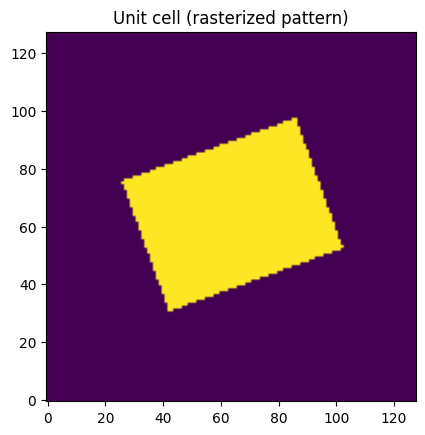

In [24]:
# Materials (all lossless dielectrics)
eps_inc = ConstantEps(1.0)          # incidence half-space: air
eps_trans = ConstantEps(1.46**2)    # transmission half-space: glass, n=1.46
eps_void = ConstantEps(1.0)         # layer background: air
eps_solid = ConstantEps(-9.4253, eps_im=0.75218)  # shape fill: n=2.1, lossless

period = 400.0
thickness = 50.0

# Geometry: rotated rectangle centered in the unit cell
xc, yc = period / 2, period / 2
w, h = 200.0, 150.0
angle = 20.0
corner_radius = 0.0
shape = Rectangle((xc, yc), (w, h), angle=angle, corner_radius=corner_radius)

# Source: single wavelength, oblique incidence (extend wl to a tensor of
# several values for a wavelength sweep -- every axis below broadcasts).
wl = torch.tensor([500.0])
theta = torch.tensor([0.0]) * torch.pi / 180.0
phi = torch.tensor([30.0]) * torch.pi / 180.0

model = build_model(shape, thickness, eps_solid, eps_void, eps_inc, eps_trans, period, wl, theta, phi)

# Preview the rasterized unit cell
plt.figure()
plt.imshow(model.spec(nx=128, ny=128).layers[0].pattern, origin="lower")
plt.title("Unit cell (rasterized pattern)")
plt.show()

# Base config: dtype/device/nx/ny/truncation/factorization are what the
# comparisons below vary; m/n are overridden per-m by run_convergence_sweep.
device = "cuda:0" if torch.cuda.is_available() else "cpu"
N = 256  # real-space grid resolution; must satisfy nx,ny >= 4*max(m_values)+1
base_config = build_config(torch.float32, device, m=1, n=1, nx=N, ny=N,
                            factorization=None, truncation="circular")

m_values = list(range(1, 16))  # m=n=1..15, large enough to reach a plateau

## Comparison 1: TVF factorization method / optimizer

Compares no TVF (`None`, plain Laurent rule) against the `"Jones"` and `"Jones_direct"` Li
factorization methods, plus the matrix-free Newton-CG optimizer variant of `"Jones"`. Faster
convergence (curve drops earlier / steeper) means fewer harmonics are needed for the same
accuracy — i.e. a cheaper solve for a target precision.

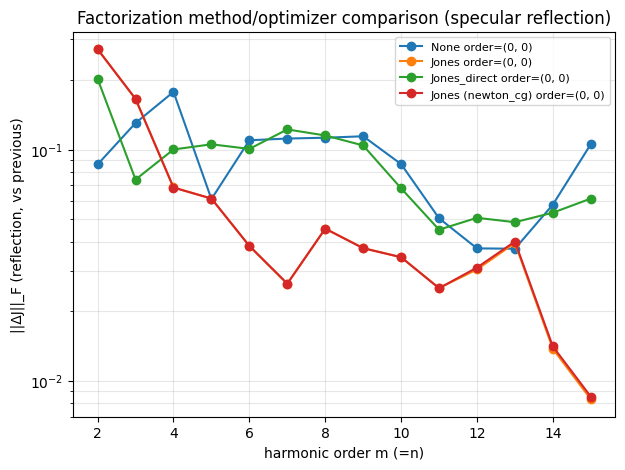

In [25]:
factorization_variants = {
    "None": replace(base_config, factorization=None),
    "Jones": replace(base_config,
                      factorization=Factorization(method="Jones", beta=0.3, gamma=0.05)),
    "Jones_direct": replace(base_config,
                             factorization=Factorization(method="Jones_direct", beta=0.3, gamma=0.05)),
    "Jones (newton_cg)": replace(base_config,
                                  factorization=Factorization(method="Jones", optimizer="newton_cg",
                                                               beta=0.3, gamma=0.05)),
}

method_results = compare_variants(model, factorization_variants, m_values)
plot_convergence(method_results, orders=[(0, 0)], kind="reflection",
                  title="Factorization method/optimizer comparison (specular reflection)")
plt.show()

## Comparison 2: circular vs. rectangular harmonic truncation

`Config.truncation="circular"` keeps only harmonics inside an ellipse
(`(m/m_max)^2+(n/n_max)^2 <= 1`) instead of the full `(2m+1)x(2n+1)` rectangle, discarding the
highest-order corner harmonics. The table below shows how many harmonics `Nh` each scheme
retains at a few values of `m`; the plot shows that despite retaining fewer harmonics, circular
truncation reaches essentially the same convergence curve — this is the whole justification for
`"circular"` being the library default.

  m   Nh (circular)   Nh (rectangular)   circular/rectangular
  1               5                  9                   0.56
  5              81                121                   0.67
 10             317                441                   0.72
 15             709                961                   0.74


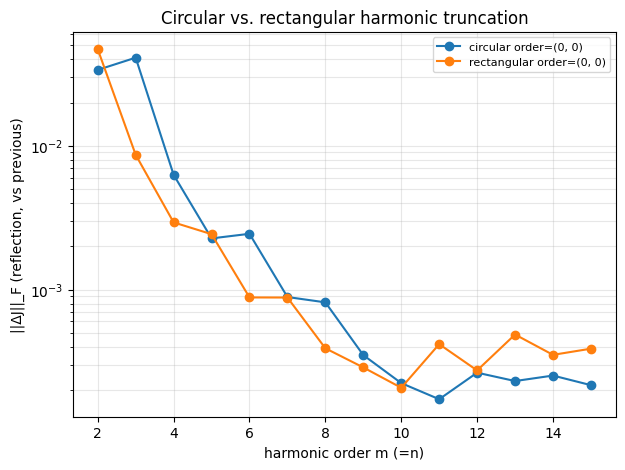

In [ ]:
# Harmonic-count savings from circular truncation
print(f"{'m':>3} {'Nh (circular)':>15} {'Nh (rectangular)':>18} {'circular/rectangular':>22}")
for m in [1, 5, 10, 15]:
    nh_c = harmonic_index_map(m, m, circular=True)[0].numel()
    nh_r = harmonic_index_map(m, m, circular=False)[0].numel()
    print(f"{m:>3} {nh_c:>15} {nh_r:>18} {nh_c / nh_r:>22.2f}")

truncation_variants = {
    "circular": replace(base_config, truncation="circular",
                         factorization=Factorization(method="Jones", beta=0.3, gamma=0.2)),
    "rectangular": replace(base_config, truncation="rectangular",
                            factorization=Factorization(method="Jones", beta=0.3, gamma=0.2)),
}

truncation_results = compare_variants(model, truncation_variants, m_values)

plot_convergence(truncation_results, orders=[(0, 0)], kind="reflection",
                  title="Circular vs. rectangular harmonic truncation")
plt.show()

## Comparison 3: float32 vs. float64 noise floor

Same structure, same factorization/truncation, only `dtype` changes. Expect both curves to
track together while harmonic-truncation error dominates, then diverge once truncation error
drops below each dtype's own precision floor: float32 should plateau higher (roundoff-limited,
roughly `1e-6`-`1e-7`) while float64 continues to a much lower floor (or wherever the solver's
own regularization/tolerances — e.g. `grazing_eps_reg`, TVF's `newton_cg_tol` — set a harder
limit). This tells you when adding more harmonics stops helping because you're precision-limited,
not truncation-limited.

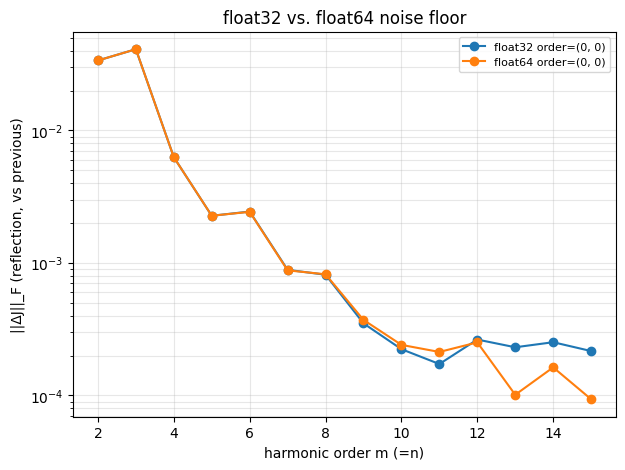

In [15]:
float_variants = {
    "float32": replace(base_config, dtype=torch.float32,
                        factorization=Factorization(method="Jones", beta=0.3, gamma=0.2)),
    "float64": replace(base_config, dtype=torch.float64,
                        factorization=Factorization(method="Jones", beta=0.3, gamma=0.2)),
}

dtype_results = compare_variants(model, float_variants, m_values)

plot_convergence(dtype_results, orders=[(0, 0)], kind="reflection",
                  title="float32 vs. float64 noise floor")
plt.show()

## Beta/gamma TVF-regularization optimization sweep

Grid-sweeps the TVF `Factorization(beta=..., gamma=...)` regularization weights and scores each
pair by how quickly the specular-reflection Jones matrix converges — either the smallest `m`
needed to drop below an error threshold, or the mean log-error across the whole `m` range. Lower
is better for both metrics. This is a `len(betas) x len(gammas) x len(m_values)` grid of solves,
so the default grid/`m` range below is kept modest; widen it once you know the runtime budget.

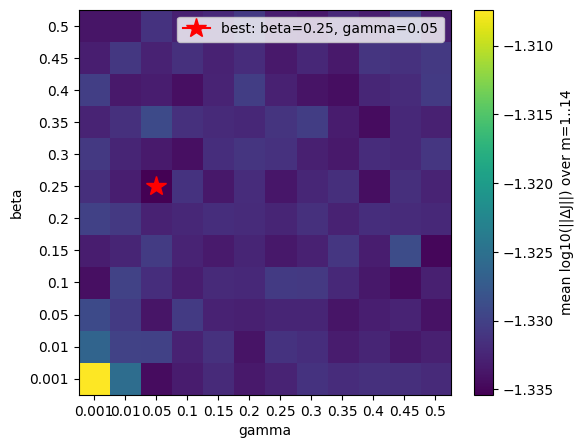

In [26]:
def sweep_beta_gamma(model: Model, base_config: Config, betas: Sequence[float], gammas: Sequence[float],
                      m_values: Sequence[int], order: Tuple[int, int] = (0, 0), kind: str = "reflection",
                      metric: str = "mean_log_error", threshold: float = 1e-4, method: str = "Jones") -> torch.Tensor:
    """Grid-sweep (beta, gamma) TVF regularization weights.

    For each (beta, gamma) pair, run a harmonic-order convergence sweep and
    reduce the resulting Cauchy error curve (`reference='previous'`) for a
    single tracked `(order, kind)` to one scalar "convergence quality" score.
    Lower is better for both metrics.

    metric='mean_log_error' (default)
        mean(log10(err)) over all m_values -- robust, always produces a
        usable score regardless of the `m_values` range.
    metric='threshold'
        Smallest m in m_values at which the error first drops below
        `threshold`. `float('nan')` if the threshold is never reached within
        `m_values` -- pick `threshold` to be actually achievable in that
        range (e.g. from a `run_convergence_sweep` plot at similar m), or
        every cell in the grid will come back NaN.

    Returns
    -------
    torch.Tensor
        Shape ``[len(betas), len(gammas)]``.
    """
    quality = torch.full((len(betas), len(gammas)), float('nan'))
    for i, beta in enumerate(betas):
        for j, gamma in enumerate(gammas):
            cfg = replace(base_config, factorization=Factorization(method=method, beta=beta, gamma=gamma))
            result = run_convergence_sweep(model, cfg, m_values, orders=(order,),
                                            label=f"beta={beta:.3g},gamma={gamma:.3g}")
            ms, err = convergence_errors(result, reference="previous")[(order, kind)]
            if metric == "threshold":
                below = (err <= threshold).nonzero(as_tuple=True)[0]
                quality[i, j] = float(ms[below[0].item()]) if len(below) else float('nan')
            elif metric == "mean_log_error":
                quality[i, j] = torch.log10(err.clamp_min(1e-300)).mean().item()
            else:
                raise ValueError("metric must be 'threshold' or 'mean_log_error'")
    return quality


def plot_beta_gamma_heatmap(betas: Sequence[float], gammas: Sequence[float], quality: torch.Tensor,
                             metric_name: str = "quality", ax=None):
    """imshow heatmap of the (beta, gamma) grid, annotating the best (lowest) cell."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(quality.numpy(), origin="lower", aspect="auto")
    ax.set_xticks(range(len(gammas))); ax.set_xticklabels([f"{g:.3g}" for g in gammas])
    ax.set_yticks(range(len(betas))); ax.set_yticklabels([f"{b:.3g}" for b in betas])
    ax.set_xlabel("gamma"); ax.set_ylabel("beta")
    plt.colorbar(im, ax=ax, label=metric_name)

    finite = quality[torch.isfinite(quality)]
    if len(finite):
        best = (quality == finite.min()).nonzero()[0]
        ax.plot(best[1].item(), best[0].item(), marker="*", color="red", markersize=15,
                label=f"best: beta={betas[best[0].item()]:.3g}, gamma={gammas[best[1].item()]:.3g}")
        ax.legend()
    return ax


betas = [0.001, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
gammas = [0.001, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
m_values_bg = list(range(1, 15))  # smaller range: keep the grid sweep affordable

quality = sweep_beta_gamma(model, base_config, betas, gammas, m_values_bg,
                            order=(0, 0), method="Jones", 
                            kind="reflection", metric="mean_log_error")

plot_beta_gamma_heatmap(betas, gammas, quality, metric_name="mean log10(||ΔJ||) over m=1..14")
plt.show()

## Reading the plots

- **A plateau** means the tracked Jones-matrix component has stopped changing meaningfully as
  `m` grows further — you've hit a floor set by something *other* than harmonic truncation
  (typically real-space grid resolution `nx,ny`, floating-point precision, or an internal solver
  tolerance such as `newton_cg_tol`), not by how many harmonics you kept.
- **A curve that never plateaus** within the `m_values` tested suggests you haven't gone to high
  enough `m` yet, or that `nx,ny` is too coarse to resolve the pattern at that `m` (the
  `run_convergence_sweep` assertion guards the minimum `nx,ny >= 4*m_max+1`, but a much finer
  grid may still be needed for sharp/high-contrast features) — or, if neither helps, may point to
  a genuine solver issue.
- **Comparing methods/variants**: a curve that drops earlier/steeper reaches a given accuracy
  with fewer harmonics, i.e. a cheaper solve — this is what `factorization_variants`,
  `truncation_variants`, `float_variants`, and the beta/gamma sweep are all measuring.

## Using this on your own structure

Build your own `Model` with `build_model(...)` (or construct one directly from `metarcwa`'s
`Model`/`Stack`/`Layer`/`Source` classes) and a `base_config` with `build_config(...)`, then reuse
`run_convergence_sweep`, `compare_variants`, `plot_convergence`, and `sweep_beta_gamma` exactly as
above — none of the helpers are specific to the rectangle example.